# Logistic Regression — Network Intrusion Detection

Huấn luyện và đánh giá mô hình **Logistic Regression** trên tập dữ liệu CICIDS2017.
Logistic Regression yêu cầu feature scaling nên ta dùng `StandardScaler` trước khi train.

In [1]:
import os
import sys
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Thêm thư mục gốc dự án vào sys.path
sys.path.insert(0, str(Path.cwd()))
sys.path.append(os.path.abspath(".."))

from src.model_training import (
    load_splits,
    evaluate_model,
    plot_confusion_matrix,
    compare_models,
)

In [2]:
# --- STEP 1: Load dữ liệu đã chia sẵn ---
print("=" * 70)
print("STEP 1: Loading pre-split data")
print("=" * 70)

X_train, X_test, y_train, y_test = load_splits()

print(f"Feature columns: {X_train.shape[1]}")
print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Classes: {sorted(y_train.unique())}")

STEP 1: Loading pre-split data
Loaded splits from disk.
Feature columns: 52
Train size: 2,016,609  |  Test size: 504,153
Classes: ['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Heartbleed', 'PortScan', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [3]:
# --- STEP 2: Feature scaling ---
print("\n" + "=" * 70)
print("STEP 2: Feature Scaling (StandardScaler)")
print("=" * 70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling applied to training and test sets.")


STEP 2: Feature Scaling (StandardScaler)
Scaling applied to training and test sets.


In [4]:
# --- STEP 3: Train Logistic Regression ---
print("\n" + "=" * 70)
print("STEP 3: Training Logistic Regression")
print("=" * 70)

t0 = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42,
    n_jobs=-1,
)

print("Fitting model on scaled training data...")
lr_model.fit(X_train_scaled, y_train)

train_time = time.time() - t0
print(f"\nTraining completed in {train_time:.2f} seconds")
print(f"Iterations per class: {lr_model.n_iter_}")


STEP 3: Training Logistic Regression
Fitting model on scaled training data...


/Users/anhoang/Documents/Projects/DAP391m/Project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Training completed in 471.38 seconds
Iterations per class: [448]


In [5]:
# --- STEP 4: Evaluate ---
print("\n" + "=" * 70)
print("STEP 4: Model Evaluation")
print("=" * 70)

y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)

lr_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred,
    model_name="Logistic Regression",
    y_pred_proba=y_pred_proba,
    labels=lr_model.classes_.tolist(),
)


STEP 4: Model Evaluation

  Logistic Regression — Evaluation Results
                            precision    recall  f1-score   support

                    BENIGN       0.99      0.98      0.99    419012
                       Bot       0.69      0.02      0.04       390
               Brute Force       0.99      0.76      0.86      1830
                      DDoS       0.99      0.97      0.98     25603
                       DoS       0.99      0.92      0.96     38749
                Heartbleed       1.00      1.00      1.00         2
                  PortScan       0.73      0.99      0.84     18139
  Web Attack � Brute Force       0.00      0.00      0.00       294
Web Attack � Sql Injection       0.00      0.00      0.00         4
          Web Attack � XSS       0.00      0.00      0.00       130

                  accuracy                           0.98    504153
                 macro avg       0.64      0.57      0.57    504153
              weighted avg       0.98      0


STEP 5: Confusion Matrix


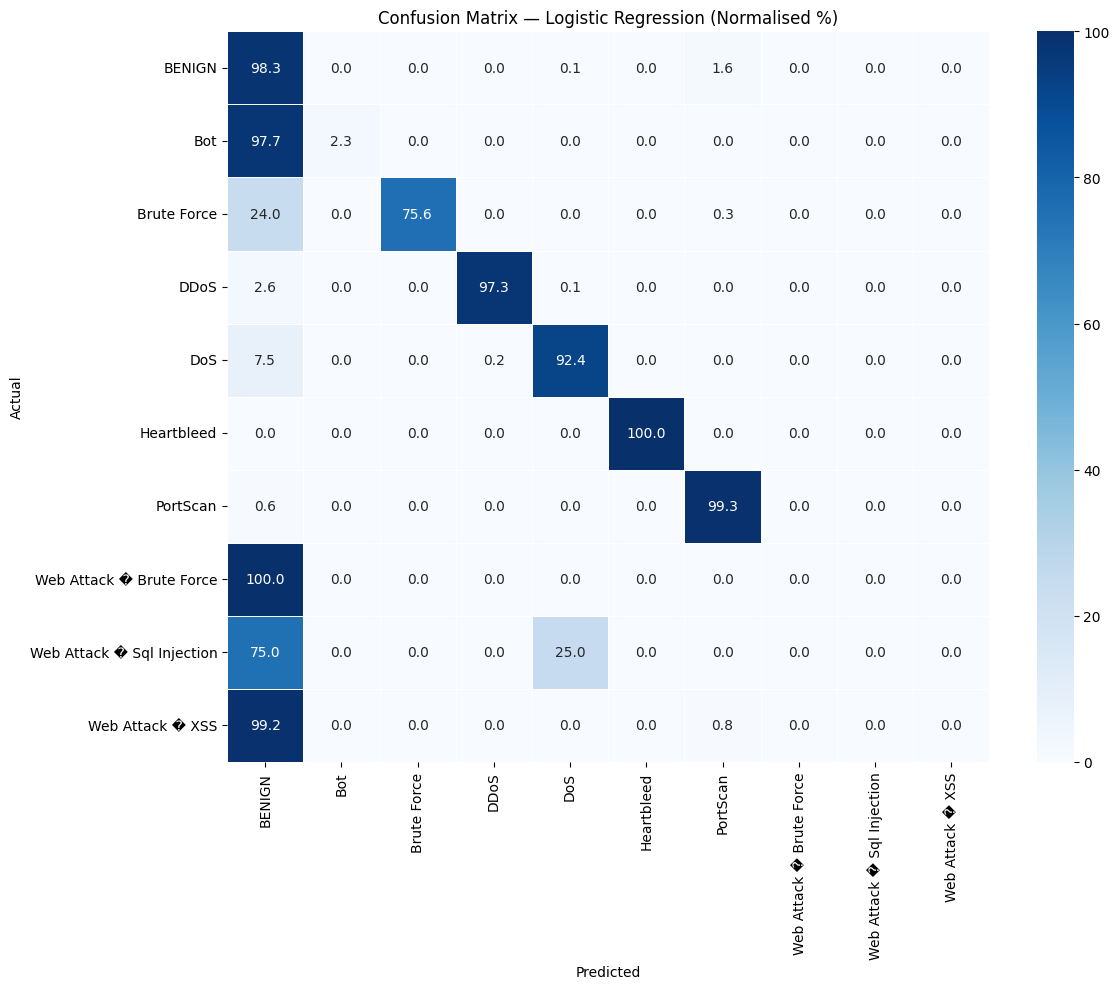

In [6]:
# --- STEP 5: Confusion Matrix ---
print("\n" + "=" * 70)
print("STEP 5: Confusion Matrix")
print("=" * 70)

plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred,
    labels=lr_model.classes_.tolist(),
    model_name="Logistic Regression",
    normalize=True,
    figsize=(12, 10),
)

In [7]:
# --- STEP 6: Summary ---
print("\n" + "=" * 70)
print("STEP 6: Summary")
print("=" * 70)

comparison_df = compare_models([lr_results])
print("\nPerformance Metrics:")
print(comparison_df.to_string(index=False))

print(f"\nTraining time : {train_time:.2f}s")
print(f"Test set size : {len(y_test):,}")
print(f"Features      : {X_train.shape[1]}")
print(f"Classes       : {len(lr_model.classes_)}")


STEP 6: Summary

Performance Metrics:
              Model  Accuracy  Precision (weighted)  Precision (macro)  Recall (weighted)  Recall (macro)  F1 (weighted)  F1 (macro)  Cohen Kappa    MCC  ROC-AUC (weighted)  ROC-AUC (macro)
Logistic Regression    0.9762                0.9785             0.6386             0.9762          0.5653         0.9762       0.567       0.9214 0.9218               0.997           0.9762

Training time : 471.38s
Test set size : 504,153
Features      : 52
Classes       : 10
